In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
output_dir = "designs/"

df_designs = []

for filename in os.listdir(output_dir):
    if not filename.startswith("rational_heuristic"):
        continue
    df_designs.append(pd.read_csv(os.path.join(output_dir, filename)))

df_designs = pd.concat(df_designs)
# remove duplicate sequences
df_designs = df_designs.drop_duplicates(subset="sequence")
# remove designs that do not start with 'GG'
df_designs = df_designs[df_designs['sequence'].str.startswith("GG")]
df_designs

,fasta_desc,sequence,model,seed,temperature,edit_dist,perplexity,sc_score_ribonanzanet,sc_score_ribonanzanet_ss
0,rational_heuristic seed=1824 temperature=0.624...,GGAUGUUCUCGAUCCAACGCAGAAGACAAAUCUGCCUGAAAGCUUC...,rational_heuristic,1824,0.624356,28,0.0,0.214350,0.500209
1,rational_heuristic seed=1824 temperature=0.624...,GGAUCUUCUCGGUCUACCGUACAAGACAAAUCUGCCCAAAAGCUUU...,rational_heuristic,1824,0.624356,25,0.0,0.251605,0.503932
2,rational_heuristic seed=1824 temperature=0.624...,GGAUGUUCUCGAUCUAGCCGAGAAGACAAAUCUGCCCGAAAGCUUC...,rational_heuristic,1824,0.624356,31,0.0,0.195171,0.376919
3,rational_heuristic seed=1824 temperature=0.624...,GGAUAUUCUCGGUCUAUCCUACAAGACAAAUCUGCCUCAAAGCUUC...,rational_heuristic,1824,0.624356,30,0.0,0.279103,0.249906
4,rational_heuristic seed=1824 temperature=0.624...,GGAUUUUCUCGGUCUAACAGAGAAGACAAAUCUGCCAGAAAGCUUG...,rational_heuristic,1824,0.624356,27,0.0,0.177796,0.766579
...,...,...,...,...,...,...,...,...,...
27440,rational_heuristic seed=5632 temperature=1.268...,GGACGUUCUCGGUCCCAAAACCAAGACAAAUCUGCCAUAAAGCUCC...,rational_heuristic,5632,1.268120,44,0.0,0.217573,0.437570
27441,rational_heuristic seed=5632 temperature=1.268...,GGACUUUCUUGGUCUAAAAAGUAAGACAAAUCUGUCAAACAGCUAA...,rational_heuristic,5632,1.268120,49,0.0,0.204632,0.548903
27442,rational_heuristic seed=5632 temperature=1.268...,GGAACUUCUCGUUUCCAAAACAAAGACAAAUCUGUCAGAUAGCUAG...,rational_heuristic,5632,1.268120,46,0.0,0.215561,0.288529
27443,rational_heuristic seed=5632 temperature=1.268...,GGACUUUCUUGGUUCCAAAACCAAGACAAAUCUGUCAGAGCGCUAU...,rational_heuristic,5632,1.268120,52,0.0,0.235935,0.280212


Number of unique designs passing filter: 30841


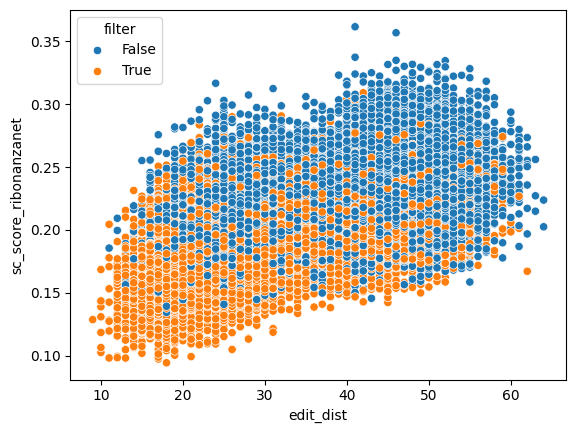

In [4]:
# Create new column 'filter' set to True if design sc_score_ribonazanet_ss >= 0.8
df_designs['filter'] = df_designs['sc_score_ribonanzanet_ss'] >= 0.5
print("Number of unique designs passing filter:", df_designs['filter'].sum())

sns.scatterplot(data=df_designs, x='edit_dist', y='sc_score_ribonanzanet', hue='filter')
plt.show()

In [5]:
top_n = 20
random_n = 20
min_edit_dist = 15
max_edit_dist = 40

df_final_designs = pd.DataFrame()
df_final_designs_random = pd.DataFrame()

for edit_dist in range(min_edit_dist, max_edit_dist):
    # filter designs by edit_dist
    _df = df_designs[df_designs.edit_dist == edit_dist]
    # add top n designs by lowest sc_score_ribonanzanet to df_final_designs
    df_final_designs = pd.concat(
        [
            df_final_designs, 
            _df[_df['filter']].sort_values(by="sc_score_ribonanzanet").head(top_n)
        ]
    )
    # add random n designs to df_final_designs_random
    df_final_designs_random = pd.concat(
        [
            df_final_designs_random, 
            _df.sample(random_n)
        ]
    )

# remove 'filter' column
df_final_designs = df_final_designs.drop(columns=['filter'])
df_final_designs_random = df_final_designs_random.drop(columns=['filter'])
# update 'model' column
df_final_designs["model"] = "rational_heuristic"
df_final_designs_random["model"] = "rational_heuristic_random"
# save final designs to csv
df_final_designs.to_csv(f"final_designs/rational_heuristic_{pd.Timestamp.now().strftime('%d%m%Y')}.csv", index=False)
df_final_designs_random.to_csv(f"final_designs/rational_heuristic_random_{pd.Timestamp.now().strftime('%d%m%Y')}.csv", index=False)
df_final_designs

,fasta_desc,sequence,model,seed,temperature,edit_dist,perplexity,sc_score_ribonanzanet,sc_score_ribonanzanet_ss
3269,rational_heuristic seed=6105 temperature=0.443...,GGGUCUUCUCGAUCUAACAAAAAAGACAAAUCUGCCACAAAGCUUG...,rational_heuristic,6105,0.443105,15,0.0,0.101880,0.827586
25150,rational_heuristic seed=1644 temperature=1.496...,GGAUCUUCUCGAUCUAACCACAAAGACAAAUCUGCCAAAAAGCUUG...,rational_heuristic,1644,1.496716,15,0.0,0.107446,0.938709
1279,rational_heuristic seed=754 temperature=0.2168...,GGAUCUUCUCGAUCUAGCGCAUAAGACAAAUCUGCCACAAAGCUUG...,rational_heuristic,754,0.216795,15,0.0,0.109742,0.561158
2105,rational_heuristic seed=4618 temperature=1.444...,GGAUCUUCUCGAUCUAUGAACAAAGACAAAUCUGCCACAAAGCUGU...,rational_heuristic,4618,1.444718,15,0.0,0.111369,0.754215
6212,rational_heuristic seed=3500 temperature=0.329...,GGGUCUUCUCGAUCUUACAAUUAAGACAAAUCUGCCAGAACGCUUG...,rational_heuristic,3500,0.329684,15,0.0,0.117067,0.692003
...,...,...,...,...,...,...,...,...,...
16795,rational_heuristic seed=6064 temperature=0.308...,GGAUUUUCUCGAUCUACCCAUAAAGACAAAUCCAUCUCAACGCUUU...,rational_heuristic,6064,0.308480,39,0.0,0.168571,0.509687
13656,rational_heuristic seed=6072 temperature=0.398...,GGAUCUUCUCGAUCCUACGUUCAAGACAAAUCUGCCCAAGCGCUUG...,rational_heuristic,6072,0.398911,39,0.0,0.168608,0.564484
21511,rational_heuristic seed=4640 temperature=0.640...,GGCUCUUCUCGAGCUCUCGAAAAAGACAAAUUUGCCGCGCAGCUUG...,rational_heuristic,4640,0.640256,39,0.0,0.168807,0.602268
14786,rational_heuristic seed=1600 temperature=1.152...,GGAGAUUCUCGCUCUACCAACAAAGACAAAUCUGCAUGCAAGCUUG...,rational_heuristic,1600,1.152792,39,0.0,0.169579,0.575811


/home/ckj24/miniforge-pypy3/envs/rna/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ckj24/miniforge-pypy3/envs/rna/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/ckj24/miniforge-pypy3/envs/rna/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/hom

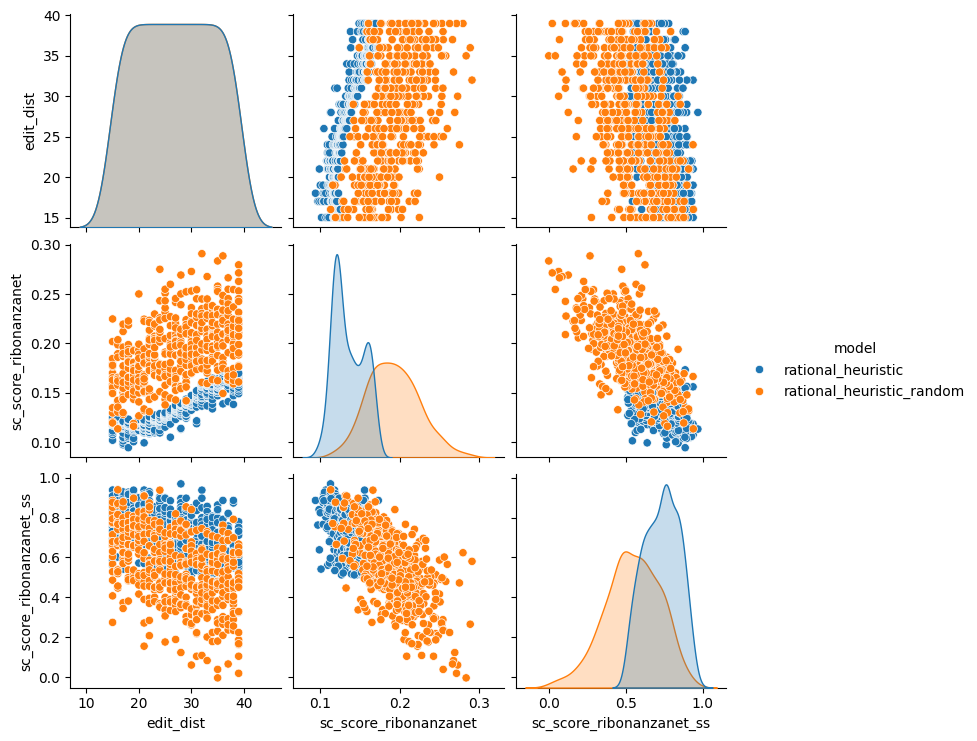

In [6]:
df_combined = pd.concat([df_final_designs, df_final_designs_random])

sns.pairplot(
    df_combined, 
    x_vars=['edit_dist', 'sc_score_ribonanzanet', 'sc_score_ribonanzanet_ss'],
    y_vars=['edit_dist', 'sc_score_ribonanzanet', 'sc_score_ribonanzanet_ss'],
    hue='model'
)
plt.show()